In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

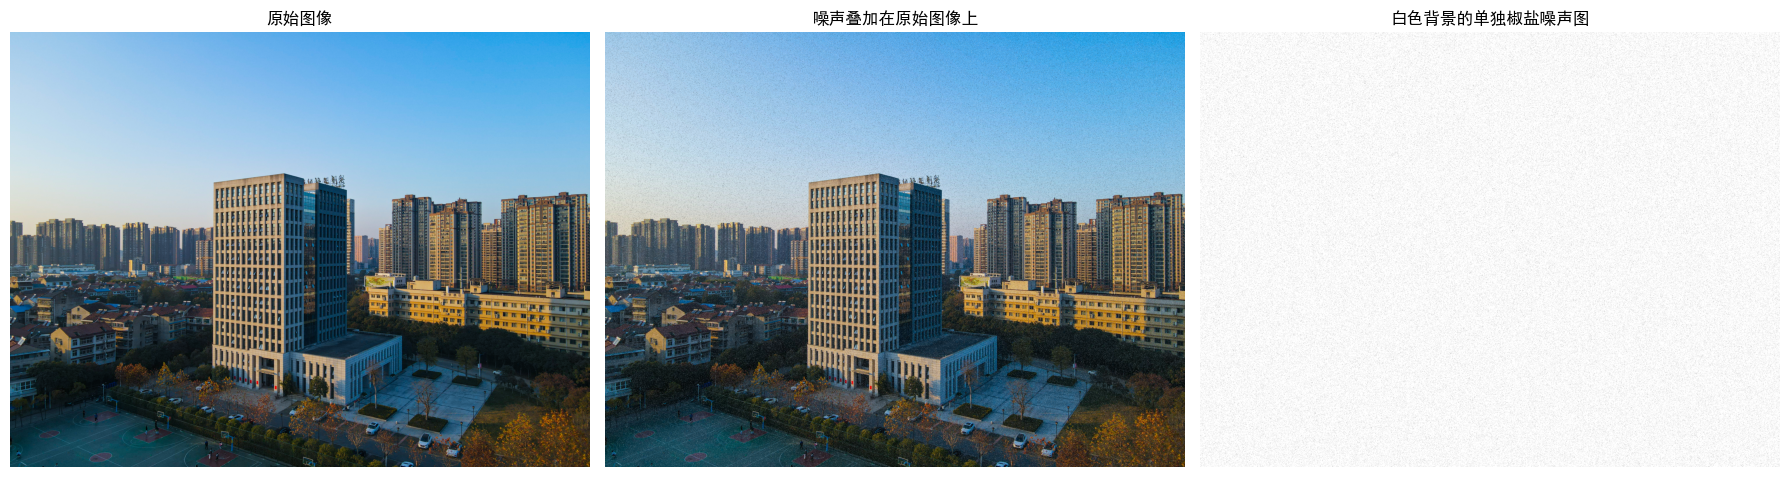

In [11]:
def add_salt_pepper_noise(image, prob=0.05):
    """
    给图像添加椒盐噪声（叠加在原始图像上）
    :param image: 输入图像（支持单通道灰度图/3通道彩色图）
    :param prob: 总噪声比例（默认 5%，盐噪声和椒噪声各占一半）
    :return: 带椒盐噪声的图像
    """
    output = np.copy(image)
    h, w = image.shape[:2]
    single_prob = prob / 2  # 单种噪声比例（盐、椒各占一半）
    noise_mask = np.random.rand(h, w)  # 统一噪声掩码，避免叠加

    # 盐噪声（白色）
    output[noise_mask < single_prob] = 255
    # 椒噪声（黑色）
    output[noise_mask > 1 - single_prob] = 0

    return output

def generate_standalone_salt_pepper_noise_white_bg(image_shape, prob=0.05):
    """
    生成白色背景的单独椒盐噪声图（无原始图像，仅包含噪声点）
    :param image_shape: 噪声图的形状（与原始图像一致，格式：(h, w) 或 (h, w, 3)）
    :param prob: 总噪声比例（默认 5%，盐、椒各占一半）
    :return: 白色背景的单独椒盐噪声图
    """
    # 核心修改：创建白色空白画布（背景值255，纯白色）
    noise_image = np.full(image_shape, 255, dtype=np.uint8)

    h, w = image_shape[:2]
    single_prob = prob / 2
    noise_mask = np.random.rand(h, w)  # 统一噪声掩码，保证盐、椒噪声互斥

    # 注意：白色背景下，盐噪声（255）与背景融合，仅能清晰看到椒噪声（0，黑色）
    # 若需同时清晰显示盐、椒噪声，可保留灰色背景，或将盐噪声改为其他颜色（如0，椒噪声改为255）
    noise_image[noise_mask < single_prob] = 255  # 盐噪声（与白色背景一致，不可见）
    noise_image[noise_mask > 1 - single_prob] = 0  # 椒噪声（黑色，与白色背景对比鲜明，清晰可见）

    return noise_image

# 读取原始图像（用于获取尺寸和通道数，确定噪声图形状）
img_path = "../img/wuhues01.jpg"
img = cv2.imread(img_path)

if img is None:
    raise ValueError(f"❌ 图像读取失败！请确保：1. {img_path} 路径存在；2. 图像文件已放入img文件夹；3. 图像格式为jpg/png等支持格式。")

# 转换为 RGB 格式（用于matplotlib正确显示）
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 生成两种图像：1. 噪声叠加图像 2. 白色背景单独噪声图
noisy_img = add_salt_pepper_noise(img)
standalone_noise_white_bg = generate_standalone_salt_pepper_noise_white_bg(img.shape)
noisy_img_rgb = cv2.cvtColor(noisy_img, cv2.COLOR_BGR2RGB)
standalone_noise_white_bg_rgb = cv2.cvtColor(standalone_noise_white_bg, cv2.COLOR_BGR2RGB)

# 显示三联对比图
plt.figure(figsize=(18, 6))

# 子图1：原始图像
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("原始图像")
plt.axis("off")

# 子图2：噪声叠加图像
plt.subplot(1, 3, 2)
plt.imshow(noisy_img_rgb)
plt.title("噪声叠加在原始图像上")
plt.axis("off")

# 子图3：白色背景的单独椒盐噪声图
plt.subplot(1, 3, 3)
plt.imshow(standalone_noise_white_bg_rgb)
plt.title("白色背景的单独椒盐噪声图")
plt.axis("off")

plt.tight_layout()
plt.show()

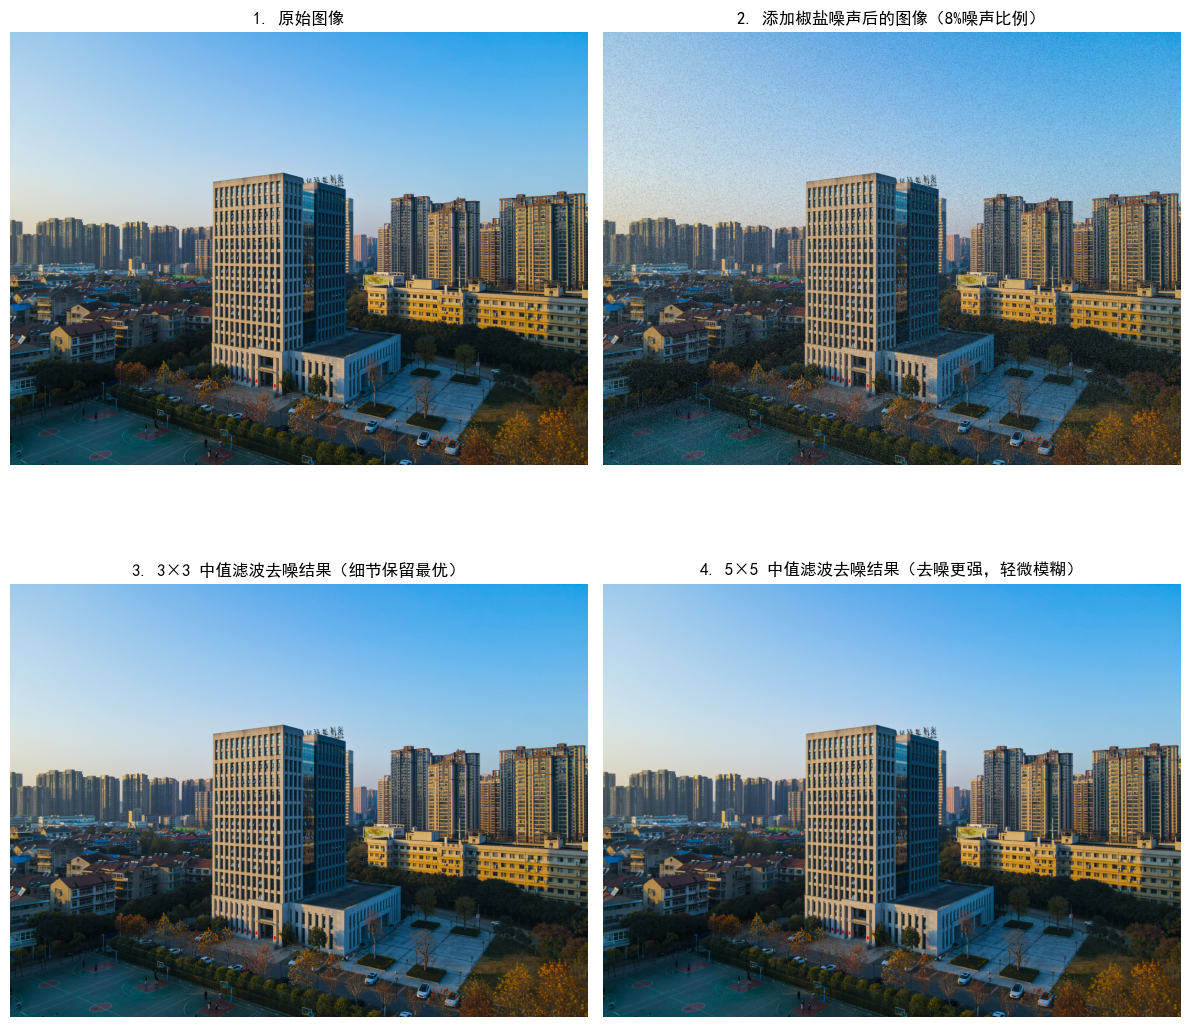

In [12]:
# 1. 读取原始图像
img_path = "../img/wuhues01.jpg"
img = cv2.imread(img_path)

if img is None:
    raise ValueError(f"❌ 图像读取失败！请确保：1. {img_path} 路径存在；2. 图像文件已放入img文件夹；3. 图像格式为jpg/png等支持格式。")

# 转换为RGB格式（用于matplotlib正确显示，OpenCV默认读取为BGR）
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. 给图像添加椒盐噪声（提高噪声比例，更易观察去噪效果）
noisy_img = add_salt_pepper_noise(img, prob=0.08)
noisy_img_rgb = cv2.cvtColor(noisy_img, cv2.COLOR_BGR2RGB)

# 3. 中值滤波去噪（两种窗口尺寸对比）
## 3.1 3×3窗口中值滤波（细节保留最优）
median_filter_3x3 = cv2.medianBlur(noisy_img, 3)  # 第二个参数为窗口尺寸，必须为奇数
median_3x3_rgb = cv2.cvtColor(median_filter_3x3, cv2.COLOR_BGR2RGB)

## 3.2 5×5窗口中值滤波（去噪效果更强，轻微模糊）
median_filter_5x5 = cv2.medianBlur(noisy_img, 5)
median_5x5_rgb = cv2.cvtColor(median_filter_5x5, cv2.COLOR_BGR2RGB)

# 4. 四图对比可视化（原始图像→带噪声图像→3×3去噪→5×5去噪）
plt.figure(figsize=(12, 12))

# 子图1：原始图像
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title("1. 原始图像")
plt.axis("off")

# 子图2：添加椒盐噪声后的图像
plt.subplot(2, 2, 2)
plt.imshow(noisy_img_rgb)
plt.title("2. 添加椒盐噪声后的图像（8%噪声比例）")
plt.axis("off")

# 子图3：3×3窗口中值滤波去噪结果
plt.subplot(2, 2, 3)
plt.imshow(median_3x3_rgb)
plt.title("3. 3×3 中值滤波去噪结果（细节保留最优）")
plt.axis("off")

# 子图4：5×5窗口中值滤波去噪结果
plt.subplot(2, 2, 4)
plt.imshow(median_5x5_rgb)
plt.title("4. 5×5 中值滤波去噪结果（去噪更强，轻微模糊）")
plt.axis("off")

# 自动调整子图间距，避免重叠
plt.tight_layout()
# 显示图像
plt.show()
